Reading the Dataset

In [82]:
# Using Python's urllib/gzip instead of wget/gzip shell commands,
# since wget is not available by default on Windows
import urllib.request
import gzip
import shutil

url = "https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/data/mnist.pkl.gz"

urllib.request.urlretrieve(url, "mnist.pkl.gz")

with gzip.open("mnist.pkl.gz", "rb") as f_in:
    with open("mnist.pkl", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

In [83]:
import pickle
with open('mnist.pkl','rb') as f:
    raw_data = pickle.load(f, encoding='latin1') # Added encoding='latin1' to fix a Python 2 vs Python 3 pickle compatibility issue

In [84]:
# The downloaded pickle file uses the (train, valid, test) tuple format,
# not the {'Train': {...}, 'Test': {...}} dict format this notebook expects.
# Manually reconstructing the expected dictionary structure here.
training_data, validation_data, test_data = raw_data

MNIST = {
    'Train': {
        'Features': training_data[0],
        'Labels': training_data[1]
    },
    'Test': {
        'Features': test_data[0],
        'Labels': test_data[1]
    }
}

In [85]:
labels = MNIST['Train']['Labels']
data = MNIST['Train']['Features']

In [86]:
data.shape

(50000, 784)

Splitting the Data

In [87]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(data,labels,test_size=0.2)

print(f"Train samples: {len(features_train)}, test samples: {len(features_test)}")

Train samples: 40000, test samples: 10000


In [88]:
%matplotlib inline
import matplotlib.cm as cm
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.decomposition import PCA
# pick the seed for reproducibility - change it to explore the effects of random variations
np.random.seed(0)
# Initialize PCA for visualization
pca = PCA(n_components=2)
pca.fit(features_train)

class Linear:
    def __init__(self,nin,nout):
        self.W = np.random.normal(0, 1.0/np.sqrt(nin), (nout, nin))
        self.b = np.zeros((1,nout))
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        
    def forward(self, x):
        self.x=x
        return np.dot(x, self.W.T) + self.b
    
    def backward(self, dz):
        dx = np.dot(dz, self.W)
        dW = np.dot(dz.T, self.x)
        db = dz.sum(axis=0)
        self.dW = dW
        self.db = db
        return dx
    
    def update(self,lr):
        self.W -= lr*self.dW
        self.b -= lr*self.db

class Softmax:
    def forward(self,z):
        self.z = z
        zmax = z.max(axis=1,keepdims=True)
        expz = np.exp(z-zmax)
        Z = expz.sum(axis=1,keepdims=True)
        return expz / Z
    def backward(self,dp):
        p = self.forward(self.z)
        pdp = p * dp
        return pdp - p * pdp.sum(axis=1, keepdims=True)
    
class CrossEntropyLoss:
    def forward(self,p,y):
        self.p = p
        self.y = y
        p_of_y = p[np.arange(len(y)), y]
        log_prob = np.log(p_of_y)
        return -log_prob.mean()
    def backward(self,loss):
        dlog_softmax = np.zeros_like(self.p)
        dlog_softmax[np.arange(len(self.y)), self.y] -= 1.0/len(self.y)
        return dlog_softmax / self.p
    
class Net:
    def __init__(self):
        self.layers = []
    
    def add(self,l):
        self.layers.append(l)
        
    def forward(self,x):
        for l in self.layers:
            x = l.forward(x)
        return x
    
    def backward(self,z):
        for l in self.layers[::-1]:
            z = l.backward(z)
        return z
    
    def update(self,lr):
        for l in self.layers:
            if 'update' in l.__dir__():
                l.update(lr)

class Tanh:
    def forward(self,x):
        y = np.tanh(x)
        self.y = y
        return y
    def backward(self,dy):
        return (1.0-self.y**2)*dy
    
# Helper functions
def get_loss_acc(x,y,loss=CrossEntropyLoss()):
    p = net.forward(x)
    l = loss.forward(p,y)
    pred = np.argmax(p,axis=1)
    acc = (pred==y).mean()
    return l,acc

def train_epoch(net, features_train, labels_train, loss=CrossEntropyLoss(), batch_size=4, lr=0.1):
    for i in range(0,len(features_train),batch_size):
        xb = features_train[i:i+batch_size]
        yb = labels_train[i:i+batch_size]

        p = net.forward(xb)
        l = loss.forward(p,yb)
        dp = loss.backward(l)
        dx = net.backward(dp)
        net.update(lr)

weight_history = []

def train_and_plot(n_epoch, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1):
    fig, ax = plt.subplots(2, 1)
    ax[0].set_xlim(0, n_epoch + 1)
    ax[0].set_ylim(0,1)

    train_acc = np.empty((n_epoch, 3))
    train_acc[:] = np.NAN
    valid_acc = np.empty((n_epoch, 3))
    valid_acc[:] = np.NAN

    for epoch in range(1, n_epoch + 1):

        train_epoch(net,features_train,labels_train,loss,batch_size,lr)

        # Collect weights for visualisation
        epoch_weights = {}
        for idx, layer in enumerate(net.layers):
            if hasattr(layer, 'W'):  # Only for Linear layers
                max_abs = np.max(np.abs(layer.W))
                epoch_weights[f'Layer {idx+1}'] = max_abs
        weight_history.append(epoch_weights)

        tloss, taccuracy = get_loss_acc(features_train,labels_train,loss)
        train_acc[epoch-1, :] = [epoch, tloss, taccuracy]
        vloss, vaccuracy = get_loss_acc(features_test,labels_test,loss)
        valid_acc[epoch-1, :] = [epoch, vloss, vaccuracy]
        
        ax[0].set_ylim(0, max(max(train_acc[:, 2]), max(valid_acc[:, 2])) * 1.1)

        plot_training_progress(train_acc[:, 0], (train_acc[:, 2],
                                                 valid_acc[:, 2]), fig, ax[0])
        plot_decision_boundary(net, fig, ax[1])
        fig.canvas.draw()
        fig.canvas.flush_events()

def plot_training_progress(x, y_data, fig, ax):
    styles = ['k--', 'g-']
    # remove previous plot
    for line in list(ax.lines):
        line.remove()
    # draw updated lines
    for i in range(len(y_data)):
        ax.plot(x, y_data[i], styles[i])
    ax.legend(ax.lines, ['training accuracy', 'validation accuracy'],
              loc='upper center', ncol = 2)

def plot_decision_boundary(net, fig, ax):
    draw_colorbar = True
    # remove previous plot
    for coll in list(ax.collections):
        coll.remove()
        draw_colorbar = False

    # generate countour grid
    features_train_2d = pca.transform(features_train)
    x_min, x_max = features_train_2d[:, 0].min() - 1, features_train_2d[:, 0].max() + 1
    y_min, y_max = features_train_2d[:, 1].min() - 1, features_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid_points = pca.inverse_transform(np.c_[xx.ravel().astype('float32'), yy.ravel().astype('float32')])
    n_classes = max(labels_train)+1
    
    # evaluate predictions
    prediction = np.array(net.forward(grid_points))
    # for two classes: prediction difference
    if (n_classes == 2):
        Z = np.array([0.5+(p[0]-p[1])/2.0 for p in prediction]).reshape(xx.shape)
    else:
        Z = np.array([p.argsort()[-1]/float(n_classes-1) for p in prediction]).reshape(xx.shape)
    
    # draw contour
    levels = np.linspace(0, 1, 40)
    cs = ax.contourf(xx, yy, Z, alpha=0.4, levels = levels)
    if draw_colorbar:
        fig.colorbar(cs, ax=ax, ticks = [0, 0.5, 1])
    c_map = [cm.jet(x) for x in np.linspace(0.0, 1.0, n_classes) ]
    colors = [c_map[l] for l in labels_train]
    ax.scatter(features_train_2d[:, 0], features_train_2d[:, 1], marker='o', c=colors, s=60, alpha = 0.5)

# One-layer Perceptron

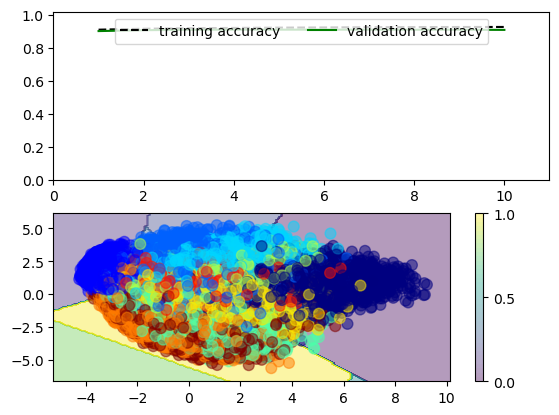

In [89]:
net = Net()
net.add(Linear(784, 10))
net.add(Softmax())

res = train_and_plot(10, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)

# Two-layer Perceptron

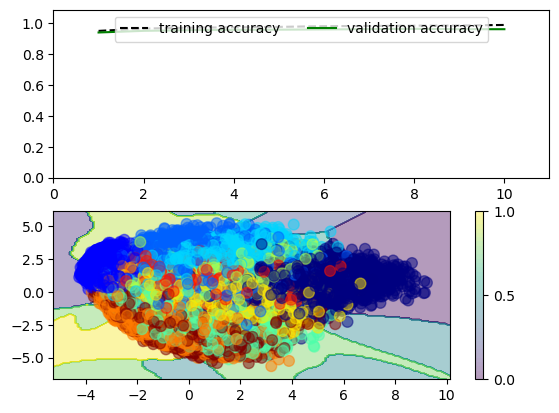

In [90]:
net = Net()
net.add(Linear(784, 100))
net.add(Tanh())
net.add(Linear(100, 10))
net.add(Softmax())

res = train_and_plot(10, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)

# Three-layer Perceptron

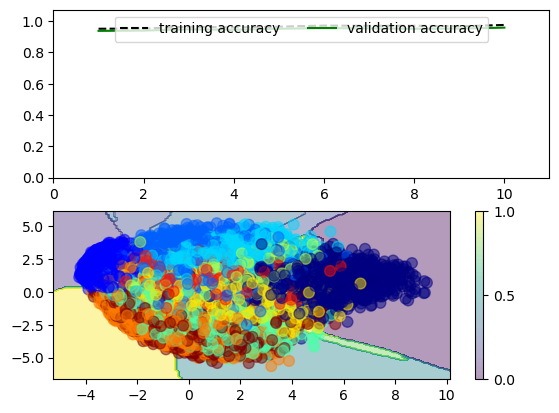

In [91]:
net = Net()
net.add(Linear(784, 100))
net.add(Tanh())
net.add(Linear(100, 50))
net.add(Tanh())
net.add(Linear(50, 10))
net.add(Softmax())

res = train_and_plot(10, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)

# Questions and Answers

1. Does the inter-layer activation function affect network performance?\n
Yes. Using Tanh improves accuracy because it enables better gradient flow during backpropagation. As layers increase, Tanh allows the network to learn more complex, curved decision boundaries.

2. Do we need 2- or 3-layered network for this task?\n
By comparing the graphs, the 2-layered network is more appropriate. The 3-layered network showed only minor accuracy improvement, meaning the extra complexity isn't justified for this task. Both can work, but the 2-layer is simpler and faster.

3. Did you experience any problems training the network? Especially as the 4. number of layers increased.\n
Yes. As layers increased, training became slower and the initial accuracy ramp-up took longer.

4. How do weights of the network behave during training? You may plot max abs value of weights vs. epoch to understand the relation.\n


NameError: name 'loss' is not defined

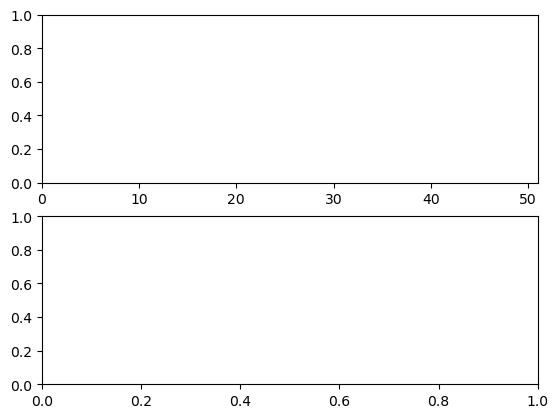

In [ ]:
# Run this cell once for each network configuration
# Save results with different names

def train_and_track_weights(net, n_epochs=50, network_name="Network"):
    """Train a network and track weight magnitudes"""
    
    weight_history = []
    
    fig, ax = plt.subplots(2, 1)
    ax[0].set_xlim(0, n_epochs + 1)
    ax[0].set_ylim(0,1)
    
    train_acc = np.empty((n_epochs, 3))
    train_acc[:] = np.NAN
    valid_acc = np.empty((n_epochs, 3))
    valid_acc[:] = np.NAN
    
    for epoch in range(1, n_epochs + 1):
        train_epoch(net, features_train, labels_train, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)
        
        # Track weights
        epoch_weights = {}
        for idx, layer in enumerate(net.layers):
            if hasattr(layer, 'W'):
                max_abs = np.max(np.abs(layer.W))
                epoch_weights[f'Layer {idx+1}'] = max_abs
        weight_history.append(epoch_weights)
        
        tloss, taccuracy = get_loss_acc(features_train, labels_train, loss)
        train_acc[epoch-1, :] = [epoch, tloss, taccuracy]
        vloss, vaccuracy = get_loss_acc(features_test, labels_test, loss)
        valid_acc[epoch-1, :] = [epoch, vloss, vaccuracy]
        
        ax[0].set_ylim(0, max(max(train_acc[:, 2]), max(valid_acc[:, 2])) * 1.1)
        plot_training_progress(train_acc[:, 0], (train_acc[:, 2], valid_acc[:, 2]), fig, ax[0])
        plot_decision_boundary(net, fig, ax[1])
        fig.canvas.draw()
        fig.canvas.flush_events()
    
    return weight_history, train_acc, valid_acc

# Now run for each network

# 1-Layer Network
np.random.seed(0)  # Reset for fair comparison
net_1layer = Net()
net_1layer.add(Linear(784, 10))  # Input directly to output
net_1layer.add(Softmax())

weight_history_1layer, train_acc_1layer, valid_acc_1layer = train_and_track_weights(
    net_1layer, n_epochs=50, network_name="1-Layer"
)

# 2-Layer Network
np.random.seed(0)  # Same seed for fair comparison
net_2layer = Net()
net_2layer.add(Linear(784, 100))
net_2layer.add(Tanh())
net_2layer.add(Linear(100, 10))
net_2layer.add(Softmax())

weight_history_2layer, train_acc_2layer, valid_acc_2layer = train_and_track_weights(
    net_2layer, n_epochs=50, network_name="2-Layer"
)

# 3-Layer Network
np.random.seed(0)  # Same seed for fair comparison
net_3layer = Net()
net_3layer.add(Linear(784, 100))
net_3layer.add(Tanh())
net_3layer.add(Linear(100, 50))
net_3layer.add(Tanh())
net_3layer.add(Linear(50, 10))
net_3layer.add(Softmax())

weight_history_3layer, train_acc_3layer, valid_acc_3layer = train_and_track_weights(
    net_3layer, n_epochs=50, network_name="3-Layer"
)